1️⃣ Load Data Hasil Preprocessing

In [29]:
# **Mount Google Drive jika menggunakan Colab**
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# **Import Library**
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [31]:
import pandas as pd

# Path ke file hasil preprocessing
processed_file_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/eda-preprocessing-data/news_data_processed.csv"

# **Load dataset yang telah diproses**
df = pd.read_csv(processed_file_path)

# **Cek apakah ada NaN**
print("Cek jumlah missing values setelah load CSV:")
print(df.isnull().sum())

# **Mengisi NaN dengan string kosong (penting untuk TF-IDF)**
df = df.fillna('')

# **Cek ulang apakah masih ada NaN**
print("\nCek ulang setelah fillna:")
print(df.isnull().sum())

# **Simpan ulang dataset yang sudah diperbaiki (opsional)**
df.to_csv(processed_file_path, index=False)


Cek jumlah missing values setelah load CSV:
title             200
date             1241
author           1317
content           109
source              0
label               0
clean_content     109
clean_text        110
topic               0
final_label         0
word_count          0
dtype: int64

Cek ulang setelah fillna:
title            0
date             0
author           0
content          0
source           0
label            0
clean_content    0
clean_text       0
topic            0
final_label      0
word_count       0
dtype: int64


2️⃣ Pisahkan Data untuk Training & Testing

In [32]:
# **Pisahkan fitur (X) dan label (y)**
X = df['clean_text']
y = df['topic']  # Label diambil dari kolom 'topic'

# **Split data menjadi 80% training & 20% testing**
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)


3️⃣ TF-IDF Vectorization

In [33]:
# **TF-IDF Vectorizer**
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# **Transformasi data dengan TF-IDF**
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


4️⃣ Train Model Naive Bayes

In [34]:
# **Inisialisasi & latih model Naive Bayes**
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


MultinomialNB()

5️⃣ Evaluasi Model

In [35]:
# **Prediksi data uji**
y_pred = model.predict(X_test_tfidf)

# **Akurasi Model**
print("\nAkurasi Model:", accuracy_score(y_test, y_pred))

# **Classification Report**
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Akurasi Model: 0.852112676056338

Classification Report:
              precision    recall  f1-score   support

    Penipuan       0.00      0.00      0.00         2
     Politik       0.78      0.95      0.86       125
        Umum       0.94      0.78      0.85       157

    accuracy                           0.85       284
   macro avg       0.57      0.58      0.57       284
weighted avg       0.86      0.85      0.85       284



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


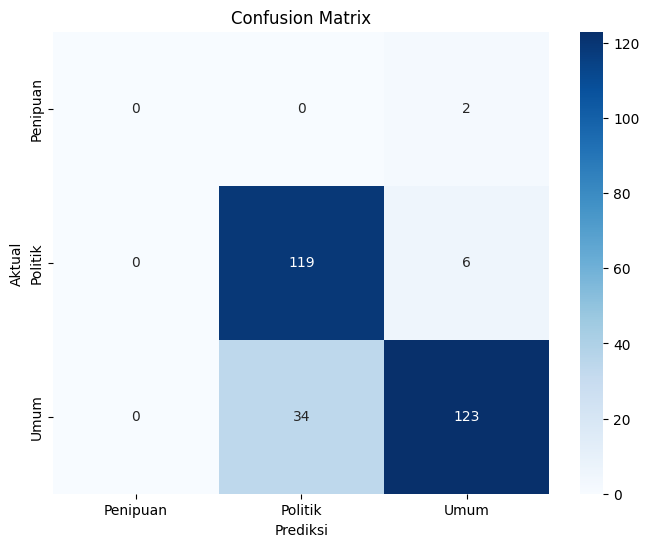

In [36]:
# **Confusion Matrix**
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


6️⃣ Simpan Model & TF-IDF Vectorizer

In [37]:
# **Simpan model & vectorizer ke Google Drive**
model_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/news_classifier.pkl"
vectorizer_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/tfidf_vectorizer.pkl"

joblib.dump(model, model_path)
joblib.dump(tfidf, vectorizer_path)

print(f"Model berhasil disimpan di: {model_path}")
print(f"TF-IDF Vectorizer berhasil disimpan di: {vectorizer_path}")


Model berhasil disimpan di: /content/drive/MyDrive/NLP Lanjut/Hoax Detection/news_classifier.pkl
TF-IDF Vectorizer berhasil disimpan di: /content/drive/MyDrive/NLP Lanjut/Hoax Detection/tfidf_vectorizer.pkl


7️⃣ Prediksi Berita Baru

In [43]:
# **Tes apakah scraping berjalan dengan baik**
news_data = scrape_cnn_news()

if len(news_data) == 0:
    print("⚠️ Scraping gagal! Tidak ada berita yang ditemukan.")
else:
    print(f"✅ Berhasil mengambil {len(news_data)} berita.")
    for i, (title, link) in enumerate(news_data[:5]):  # Tampilkan 5 berita pertama
        print(f"{i+1}. {title} - {link}")


⚠️ Scraping gagal! Tidak ada berita yang ditemukan.


In [45]:
import requests
from bs4 import BeautifulSoup
import joblib
import re
import pandas as pd

# **1️⃣ Load Model & TF-IDF Vectorizer**
model_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/news_classifier.pkl"
vectorizer_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/tfidf_vectorizer.pkl"

model = joblib.load(model_path)
tfidf = joblib.load(vectorizer_path)

# **2️⃣ Fungsi untuk Preprocessing Teks**
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # Hapus spasi berlebih
    return text

# **3️⃣ Scraping Berita dari Detik.com**
def scrape_detik_news():
    url = "https://www.detik.com/tag/politik"  # Halaman berita politik Detik
    response = requests.get(url)

    if response.status_code != 200:
        print("⚠️ Gagal mengakses halaman Detik. Status Code:", response.status_code)
        return []

    soup = BeautifulSoup(response.text, "html.parser")

    # Ambil headline berita (Detik biasanya ada di class 'media__title')
    headlines = soup.find_all("h2", class_="title")[:10]

    if not headlines:
        print("⚠️ Gagal menemukan berita di halaman. Struktur HTML mungkin berubah.")
        return []

    news_list = []
    for headline in headlines:
        title = headline.get_text(strip=True)
        link = headline.find("a")["href"] if headline.find("a") else "No link"
        news_list.append((title, link))

    return news_list

# **4️⃣ Coba Scraping & Debug**
news_data = scrape_detik_news()

if len(news_data) == 0:
    print("⚠️ Scraping gagal! Tidak ada berita yang ditemukan.")
else:
    print(f"✅ Berhasil mengambil {len(news_data)} berita.")
    for i, (title, link) in enumerate(news_data[:5]):  # Tampilkan 5 berita pertama
        print(f"{i+1}. {title} - {link}")

# **5️⃣ Jika Scraping Berhasil, Lakukan Prediksi**
predictions = []
if len(news_data) > 0:
    for title, link in news_data:
        cleaned_text = clean_text(title)  # Preprocessing judul berita
        tfidf_news = tfidf.transform([cleaned_text])  # Transform ke TF-IDF
        prediction = model.predict(tfidf_news)[0]  # Prediksi dengan model
        predictions.append((title, link, prediction))

    # **6️⃣ Simpan & Tampilkan Hasil**
    df_news = pd.DataFrame(predictions, columns=["Judul", "Link", "Prediksi Kategori"])
    df_news["Prediksi Kategori"] = df_news["Prediksi Kategori"].apply(lambda x: f"{x} (hoax)" if "hoax" in x.lower() else f"{x} (non-hoax)")

    from IPython.display import display
    display(df_news)  # Tampilkan dataframe

    # **7️⃣ Simpan ke CSV**
    csv_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/prediksi_berita.csv"
    df_news.to_csv(csv_path, index=False)

    print(f"✅ Prediksi berita telah disimpan dalam CSV: {csv_path}")


✅ Berhasil mengambil 10 berita.
1. Kebahagiaan Asila Maisa Usai Pelantikan Ramzi Sebagai Wakil Bupati Cianjur - No link
2. Sekjen PDIP Hasto Ditahan KPK, Tangannya Diborgol - No link
3. Kesejahteraan dan Integrasi Politik - No link
4. Teka-teki Sosok Si Ndablek - No link
5. Beda-beda Komentar soal 'Koalisi Permanen' Prabowo - No link


,Judul,Link,Prediksi Kategori
0,Kebahagiaan Asila Maisa Usai Pelantikan Ramzi ...,No link,Politik (non-hoax)
1,"Sekjen PDIP Hasto Ditahan KPK, Tangannya Diborgol",No link,Politik (non-hoax)
2,Kesejahteraan dan Integrasi Politik,No link,Politik (non-hoax)
3,Teka-teki Sosok Si Ndablek,No link,Umum (non-hoax)
4,Beda-beda Komentar soal 'Koalisi Permanen' Pra...,No link,Politik (non-hoax)
5,Kelakar Shanty soal Penampilan Denny Cagur Jad...,No link,Politik (non-hoax)
6,"Pakai Sarung-Peci, Kaesang Sowan ke Cak Imin d...",No link,Politik (non-hoax)
7,Relawan Prabowo-Gibran Penuhi Stadion Gelora D...,No link,Umum (non-hoax)
8,Begini Situasi Kampanye Akbar Ganjar Pranowo d...,No link,Politik (non-hoax)
9,Giliran Nelayan Brebes yang Curhat ke Ganjar,No link,Politik (non-hoax)


✅ Prediksi berita telah disimpan dalam CSV: /content/drive/MyDrive/NLP Lanjut/Hoax Detection/prediksi_berita.csv
